# **"Internship Task by Decodelabs"**

- **Intership Duration : 25th-April-2026 - 25th-May-2026**

- **Project : 2**

     **Task : 1 - Data Collection & Data Understanding**

     **Task : 2 - Data Cleaning & Preprocessing**

     **Task : 3 - Exploratory Data Analysis (EDA)**


     **Task : 4 - Data Visualization**

     **Task : 5 - Predictive Model or Insight Project**

- **Data Source : From Kaggle**

- **DataSet Name : Finance Loan Approval Prediction**

- **Domain : Data Science**

- **Submitted By : Palwasha Mushtaq**


# **Data Introduction:**

**Loan approval prediction is an important problem in the finance and banking sector. Financial companies receive a large number of loan applications every day, and manually checking each application can be time-consuming and inefficient. To reduce risk and improve decision-making, companies use customer information such as income, education, marital status, credit history, and loan amount to determine whether a loan should be approved or rejected.**

**The main objective of this project is to build a machine learning model that can predict loan eligibility based on customer details provided during the loan application process. By automating the loan approval process, financial institutions can make faster, more accurate, and more consistent decisions while reducing human effort and minimizing the risk of loan default.**

**This dataset contains demographic and financial information of applicants, including features such as Gender, Married Status, Dependents, Education, Applicant Income, Coapplicant Income, Loan Amount, Credit History, and Property Area. The target variable is Loan_Status, which indicates whether the loan application was approved or not.**

**In this project, Exploratory Data Analysis (EDA), data preprocessing, missing value treatment, outlier handling, and machine learning classification algorithms will be applied to analyze the data and predict loan approval status effectively.**

**Import Libraries:**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

# **Load/Read DataSet**

In [2]:
df=pd.read_csv('finance laon approval prdiction.csv')
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


# **Data Overview/Data Understanding**

In [3]:
print("DATA SHAPE \n",df.shape)
print("=====================================================================================")
print("DATA COLUMNS \n",df.columns)
print("=====================================================================================")
print("DATA INFO \n",df.info())
print("=====================================================================================")
print("DATA DESCRIPTION \n",df.describe())
print("=====================================================================================")
print("LOAN APPROVAL COUNT \n",df['Loan_Status'].value_counts())
print("LOAN APPROVAL PERCENTAGE \n",df["Loan_Status"].value_counts(normalize=True)*100)

DATA SHAPE 
 (614, 13)
DATA COLUMNS 
 Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11

**After reviewing the dataset, it is observed that the data contains 614 rows and 13 columns with a RangeIndex from 0 to 613. The dataset includes different data types such as float64 (4 columns), int64 (1 column), and object/string (8 columns). Some columns contain missing values, which will require preprocessing before model building. The target variable Loan_Status shows that approximately 68.72% of customers were approved for loans, while 31.27% were rejected, indicating a moderately imbalanced classification problem.**

# **Data Preprocessing**

- **Check Missing Values**

In [4]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

- **Check Duplicates Values**

In [5]:
print(df.duplicated().sum())

0


**The dataset was checked for data quality issues, including missing values and duplicate records. No duplicate entries were found in the dataset. However, several columns contain missing values, including Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History. Therefore, missing value treatment will be required before proceeding with data analysis and machine learning model building.**

- **Handling Missing Vlues**

In [6]:
cols = ['Gender','Married','Dependents','Loan_Amount_Term','Self_Employed','Credit_History']
df[cols] = df[cols].apply(lambda x: x.fillna(x.mode()[0]))

df.fillna({'LoanAmount': df['LoanAmount'].median()}, inplace=True)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [7]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

**Missing values in categorical columns such as Gender, Married, Dependents, Loan_Amount_Term, Self_Employed, and Credit_History were filled using mode imputation because mode represents the most frequent category in each column and helps preserve the original distribution of the data. The missing values in the numerical column LoanAmount were filled using the median, as this feature may contain skewness and outliers. Median is more robust to extreme values and provides a better central representation than mean for skewed financial data.**

**Hence, after rechecking the dataset using the isnull() function, it was confirmed that all missing values had been successfully filled.**

- **Drop Unnecessary Columns**

In [8]:
df.drop(columns=['Loan_ID'], inplace=True)
print(df)

     Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes         3+      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             8072   
612    Male     Yes          2      Graduate            No             7583   
613  Female      No          0      Graduate           Yes             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

# **Exploratory Data Analysis(EDA)**

- **Statistical Analysis**

   Statistical analysis is performed to understand the distribution, central tendency, and variability of numerical data. It also helps identify skewness and outliers before model building.

In [9]:
print('APPLICANT INCOME MEAN:', df['ApplicantIncome'].mean())
print('APPLICANT INCOME MEDIAN:', df['ApplicantIncome'].median())
print('APPLICANT INCOME MODE:', df['ApplicantIncome'].mode()[0])
print('APPLICANT INCOME STANDARD DEVIATION:', df['ApplicantIncome'].std())
print('APPLICANT INCOME VARIANCE:', df['ApplicantIncome'].var())
print("=====================================================================================")
print('LOAN AMOUNT MEAN:', df['LoanAmount'].mean())
print('LOAN AMOUNT MEDIAN:', df['LoanAmount'].median())
print('LOAN AMOUNT MODE:', df['LoanAmount'].mode()[0])
print('LOAN AMOUNT STANDARD DEVIATION:', df['LoanAmount'].std())
print('LOAN AMOUNT VARIANCE:', df['LoanAmount'].var())

APPLICANT INCOME MEAN: 5403.459283387622
APPLICANT INCOME MEDIAN: 3812.5
APPLICANT INCOME MODE: 2500
APPLICANT INCOME STANDARD DEVIATION: 6109.041673387178
APPLICANT INCOME VARIANCE: 37320390.16718121
LOAN AMOUNT MEAN: 145.75244299674267
LOAN AMOUNT MEDIAN: 128.0
LOAN AMOUNT MODE: 128.0
LOAN AMOUNT STANDARD DEVIATION: 84.10723338042614
LOAN AMOUNT VARIANCE: 7074.026706909469


- **The statistical analysis shows that the average applicant income is 5403.46, while the median income is 3812.5 and the mode is 2500. Since the mean is significantly higher than the median and mode, it indicates that the income distribution is positively skewed due to the presence of high-income outliers. The high standard deviation and variance also show that applicant incomes vary widely across the dataset.**

- **Similarly, the average loan amount is 145.75, whereas both the median and mode are 128, indicating that most applicants receive loan amounts around this value. The difference between mean and median suggests slight skewness in the loan amount distribution. Additionally, the standard deviation and variance indicate moderate variability in loan amounts among applicants.**

- **Groupby Analysis**

In [10]:
print(df.groupby('Loan_Status')['LoanAmount'].mean())
print('=====================================================================================')
print(df.groupby('Loan_Status')['ApplicantIncome'].mean())
print('=====================================================================================')
print(df.groupby('Education')['ApplicantIncome'].mean())

Loan_Status
N    149.890625
Y    143.869668
Name: LoanAmount, dtype: float64
Loan_Status
N    5446.078125
Y    5384.068720
Name: ApplicantIncome, dtype: float64
Education
Graduate        5857.433333
Not Graduate    3777.283582
Name: ApplicantIncome, dtype: float64


**The analysis shows that Applicant Income and Loan Amount have only a slight difference between approved and rejected loans, indicating weak direct influence. However, Education level shows a clear difference in income, suggesting it is an important factor affecting financial status.**

- **Credit History VS Loan Status LOAN (in Crosstab)**

    Crosstab is used to analyze the relationship between two categorical variables by showing their frequency distribution in a tabular form.

In [11]:
pd.crosstab(df['Credit_History'], df['Loan_Status'])

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,110,415


**Credit history has a very strong impact on loan approval. Applicants with good credit history (1.0) are far more likely to get loan approval compared to those with poor credit history (0.0).**

- **CHI-SQUARE TEST**

    The Chi-Square test checks whether there is a relationship between two categorical variables or whether they are independent of each other.

In [12]:
table = pd.crosstab(df['Credit_History'], df['Loan_Status'])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 3.418349997909119e-40


**The Chi-Square test resulted in a very small p-value (3.41e-40), which indicates a statistically significant relationship between Credit History and Loan Status. Therefore, credit history is a strong predictor of loan approval.**

- **SKEWNESS CHECK**

    Check Skewness whether the data is evenly distributed or tilted to one side, and it also helps in identifying extreme values (outliers) in numerical data.

In [13]:
print(df[['ApplicantIncome','LoanAmount']].skew())

ApplicantIncome    6.539513
LoanAmount         2.743053
dtype: float64


**Both ApplicantIncome and LoanAmount are positively skewed, with ApplicantIncome showing extreme skewness. This indicates the presence of high-value outliers, and transformation techniques like log scaling may be required before model training.**

- **Data Visualization**

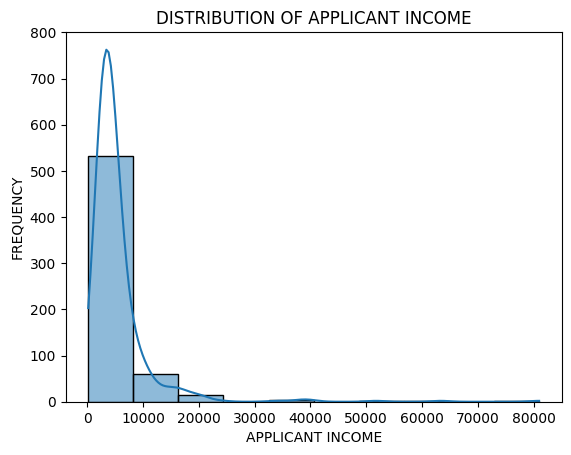

In [14]:
sns.histplot(df['ApplicantIncome'],bins = 10,kde=True)
plt.title('DISTRIBUTION OF APPLICANT INCOME')
plt.xlabel('APPLICANT INCOME')
plt.ylabel('FREQUENCY')
plt.show()

**The histogram of Applicant Income shows that most applicants fall in the lower income range. Fewer applicants are seen in the higher income range, meaning high-income individuals are less common. This results in a right-skewed distribution, where the data is concentrated on the lower side with a few high-income outliers on the right.**

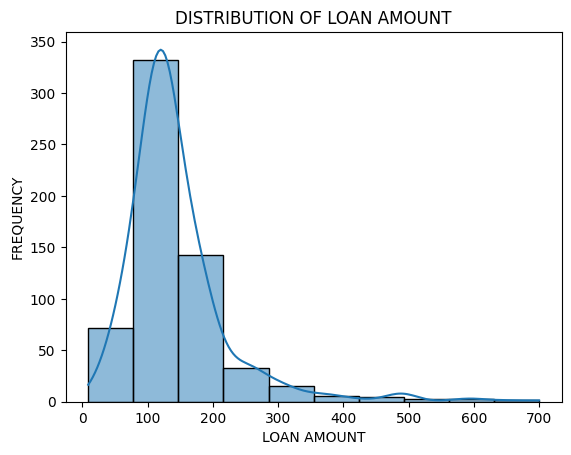

In [15]:
sns.histplot(df['LoanAmount'],bins = 10,kde=True)
plt.title('DISTRIBUTION OF LOAN AMOUNT')
plt.xlabel('LOAN AMOUNT')
plt.ylabel('FREQUENCY')
plt.show()

**The histogram shows the distribution of loan amounts given to applicants. It can be observed that most of the loan amounts are concentrated in the lower range (around 100–200)., while fewer applicants receive very high loan amounts. This creates a right-skewed distribution, meaning the data is not evenly spread and is pulled towards higher values due to a few large loans (outliers).**

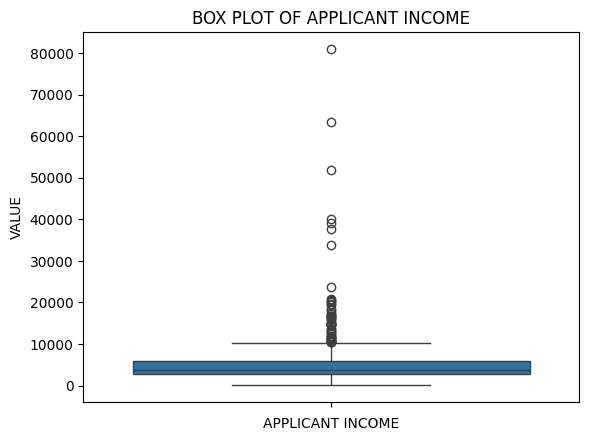

In [16]:
sns.boxplot(df['ApplicantIncome'])
plt.title('BOX PLOT OF APPLICANT INCOME')
plt.xlabel('APPLICANT INCOME')
plt.ylabel('VALUE')
plt.show()

**The box plot shows the distribution and outliers in applicant income. Most applicants have income in the lower range (around 3000–6000).The middle line (median) shows typical income around that range.There are many outliers above 10,000, some even reaching 80,000+.**

**Hence: Applicant income is highly spread and right-skewed, with a large number of extreme high-income outliers compared to the majority of applicants.**


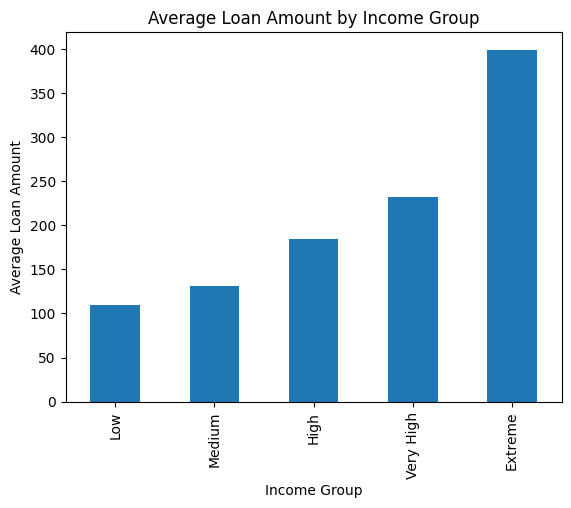

In [17]:
df['Income_Group'] = pd.cut(
    df['ApplicantIncome'],
    bins=[0,3000,6000,9000,20000,90000],
    labels=['Low','Medium','High','Very High','Extreme']
)

avg_loan = df.groupby('Income_Group')['LoanAmount'].mean()

avg_loan.plot(kind='bar')

plt.title("Average Loan Amount by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Loan Amount")

plt.show()

**The graph shows the average loan amount across different income groups. It can be observed that applicants with higher income levels generally receive higher loan amounts. Lower-income applicants tend to receive smaller loans, while high and very high-income groups have comparatively larger average loan amounts. This indicates a positive relationship between applicant income and loan approval amount.**

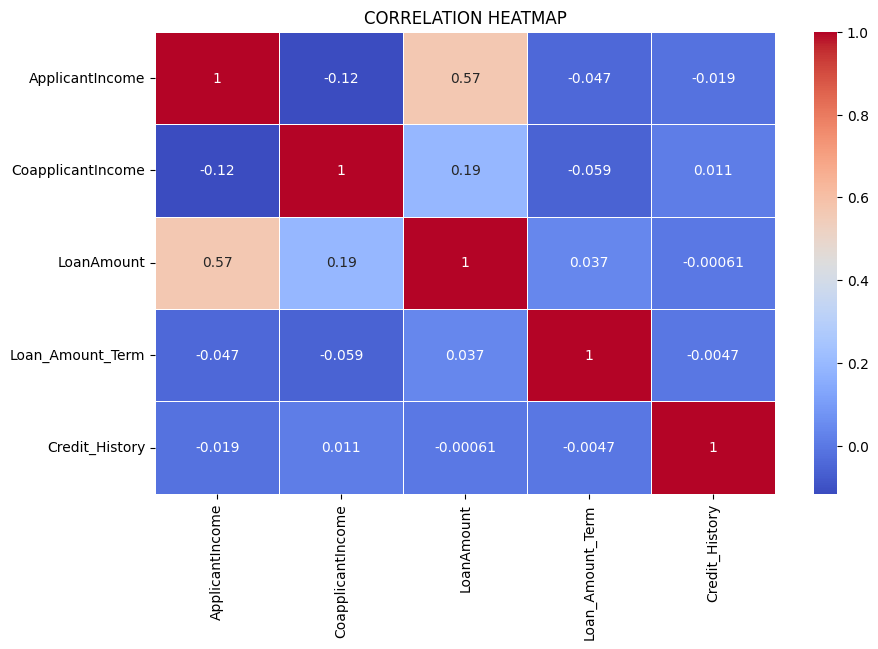

In [18]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('CORRELATION HEATMAP')
plt.show()

**The above correlation heatmap shows the relationships between different numerical variables in the dataset.**

- **Applicant Income & Loan Amount = 0.57 (Moderate positive correlation)**
This indicates that higher applicant income is generally associated with higher loan amounts.
- **Coapplicant Income & Loan Amount = 0.19 (Weak positive correlation)**
This shows a slight relationship, but coapplicant income does not strongly influence the loan amount.
- **Credit History & other variables ≈ 0 (Very weak or no linear correlation)**
Credit history does not show a strong linear relationship with the numerical features in this view.
- **Loan Amount Term (Very weak correlation with other variables)**
Loan term does not significantly correlate with income or loan amount in this dataset.

**Overall, Applicant Income is the only variable showing a noticeable relationship with Loan Amount, while the other features exhibit weak or negligible linear correlations.**

- **GroupBy Analysis & Feature Removal**

In [19]:
df= df.drop(['Income_Group'], axis = 1)

**During exploratory data analysis, group-by analysis was performed on selected (ApplicantIncome) to understand their relationship with the target variable. However, the derived feature (Income_Group) was later removed from the dataset as it was not suitable for model training and was causing issues during SMOTE processing**

- **Encoding**

In [20]:
le = LabelEncoder()
df[['Gender','Married','Education','Self_Employed','Loan_Status']]  = df[['Gender','Married','Education','Self_Employed','Loan_Status']].apply(le.fit_transform)

print('\n LABEL ENCODING(GENDER,MARRIED,EDUCATION,SELF_EMPLOYED,LOAN_STATUS)')
print(df[['Gender','Married','Education','Self_Employed','Loan_Status']])


 LABEL ENCODING(GENDER,MARRIED,EDUCATION,SELF_EMPLOYED,LOAN_STATUS)
     Gender  Married  Education  Self_Employed  Loan_Status
0         1        0          0              0            1
1         1        1          0              0            0
2         1        1          0              1            1
3         1        1          1              0            1
4         1        0          0              0            1
..      ...      ...        ...            ...          ...
609       0        0          0              0            1
610       1        1          0              0            1
611       1        1          0              0            1
612       1        1          0              0            1
613       0        0          0              1            0

[614 rows x 5 columns]


In [21]:
df= pd.get_dummies(df, columns=['Dependents','Property_Area'], dtype=int)
print('\n ONE-HOT ENCODING(DEPENDENTS,PROPERTY_AREA)')
print(df.head())


 ONE-HOT ENCODING(DEPENDENTS,PROPERTY_AREA)
   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       1        0          0              0             5849   
1       1        1          0              0             4583   
2       1        1          0              1             3000   
3       1        1          1              0             2583   
4       1        0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Loan_Status  Dependents_0  Dependents_1  Dependents_2  Dependents_3+  \
0            1             1             0             0            

- **Split Data For Training and Testing**

In [22]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("TRAINING DATA:\n", X_train)
print("TESTING DATA:\n", X_test)

TRAINING DATA:
      Gender  Married  Education  Self_Employed  ApplicantIncome  \
83        1        1          0              0             6000   
90        1        1          0              0             2958   
227       1        1          0              0             6250   
482       1        1          0              0             2083   
464       1        0          0              0             4166   
..      ...      ...        ...            ...              ...   
71        1        1          1              1             1875   
106       1        1          0              0            11417   
270       0        0          0              0             3237   
435       0        1          0              0            10047   
102       1        1          0              0            13650   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
83              2250.0       265.0             360.0             1.0   
90              2900.0       131.0 

- **Apply Standard Scaler**

In [23]:
standardscaler = StandardScaler()
col = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
X_train[col] = standardscaler.fit_transform(X_train[col])
X_test[col] = standardscaler.transform(X_test[col])    
print("STANDARD SCALED TRAINING DATA:\n", X_train[col].head(5))
print("STANDARD SCALED TESTING DATA:\n", X_test[col].head(5))

STANDARD SCALED TRAINING DATA:
      ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term
83          0.083915           0.180667    1.355734          0.287611
90         -0.429338           0.385430   -0.197609          0.287611
227         0.126095           0.005831    0.718168          0.287611
482        -0.576970           0.464185   -0.232385          0.287611
464        -0.225522          -0.528127   -0.580149          0.287611
STANDARD SCALED TESTING DATA:
      ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term
350         0.604085          -0.528127    0.926826          0.287611
377        -0.201226          -0.528127   -0.209201          0.287611
163        -0.225353          -0.072293    0.115378          0.287611
609        -0.439124          -0.528127   -0.893136          0.287611
132        -0.469831          -0.528127   -0.904728          0.287611


**StandardScaler is applied to numerical features like 'ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term' to normalize their values. This ensures that all features are on a similar scale, which helps the model perform more effectively and improves convergence.**

**SMOTE (for Imbalanced Data)**

In [24]:
sm = SMOTE(random_state = 42)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [25]:
print("Before SMOTE:")
print(y_train.value_counts(normalize=True) * 100)

print("\nAfter SMOTE:")
print(y_res.value_counts(normalize=True) * 100)

Before SMOTE:
Loan_Status
1    69.653768
0    30.346232
Name: proportion, dtype: float64

After SMOTE:
Loan_Status
0    50.0
1    50.0
Name: proportion, dtype: float64


**The dataset initially had an imbalanced distribution, where 69.65% of applications were approved (Loan_Status = Y) and 30.35% were rejected (Loan_Status = N). This imbalance could bias the model toward predicting loan approvals more frequently. To handle this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied, which generated synthetic samples for the minority class. After applying SMOTE, the dataset became perfectly balanced with 50% approved (Y) and 50% rejected (N), improving the model’s ability to learn both classes equally and make more reliable predictions..**

# **Model Building**

- **Logistic Regression Model**

In [26]:
lr_model = LogisticRegression(max_iter=500,random_state = 42)
lr_model.fit(X_res, y_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**The Logistic Regression model was trained on SMOTE-balanced data to improve the prediction of both loan approval (Y) and rejection (N) classes, ensuring fair learning from the previously imbalanced dataset.**

In [27]:
y_pred_lr = lr_model.predict(X_test)
print(y_pred_lr)

[1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1
 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 0 1 1 1 0 1 1 1 0 1 1 1]


**The Logistic Regression model predicts loan approval (1) or rejection (0) for each applicant in the test dataset, based on the learned patterns from the SMOTE-balanced training data.**

- **K-Nearest Neighbors Model**

In [28]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_res, y_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**The KNN (K-Nearest Neighbors) model was trained on SMOTE-balanced data to improve the prediction of both loan approval (Y) and rejection (N) classes, helping the model learn patterns from both classes more effectively.**

In [29]:
y_pred_knn = knn_model.predict(X_test)
print(y_pred_knn)

[1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 0 0 0 1
 1 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0
 0 0 0 1 1 1 1 1 0 0 0 1]


**The KNN (K-Nearest Neighbors) model predicts loan approval (1) or rejection (0) for each applicant in the test dataset by analyzing the similarity between applicants based on the SMOTE-balanced training data.**

# **Data Evaluation**

- **Classification Report**

In [30]:
print("LOGISTC REGRESSION CLASSIFICATION REPORT:\n", classification_report(y_test, y_pred_lr))
print("K_NEAREST_NEIGHBORS CLASSIFICATION REPORT:\n", classification_report(y_test, y_pred_knn))

LOGISTC REGRESSION CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.73      0.51      0.60        43
           1       0.77      0.90      0.83        80

    accuracy                           0.76       123
   macro avg       0.75      0.71      0.72       123
weighted avg       0.76      0.76      0.75       123

K_NEAREST_NEIGHBORS CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.49      0.49      0.49        43
           1       0.72      0.72      0.72        80

    accuracy                           0.64       123
   macro avg       0.61      0.61      0.61       123
weighted avg       0.64      0.64      0.64       123



# **Model Comparison**

- **Logistic Regression :**
The Logistic Regression model achieved an accuracy of 76%, outperforming the KNN model. It showed strong performance in predicting approved loans (Class 1) with a recall of 90% and an F1-score of 83%. For rejected loans (Class 0), the model achieved moderate performance with a precision of 73% and recall of 51%. Overall, Logistic Regression provided more balanced and reliable predictions for the loan approval dataset.

- **K-Nearest Neighbors :**
The KNN model achieved an accuracy of 64%, which was lower than Logistic Regression. It performed reasonably well in predicting approved loans (Class 1) with an F1-score of 72%, but struggled to correctly identify rejected loans (Class 0), where both precision and recall were 49%. This indicates that the KNN model was less effective in distinguishing between the two classes compared to Logistic Regression.

**Hence: Among both models, Logistic Regression performed better than K-Nearest Neighbors in terms of accuracy, recall, and overall classification performance. Therefore, Logistic Regression is the more suitable model for predicting loan approval in this project.**

- **Confusion Matrixs**

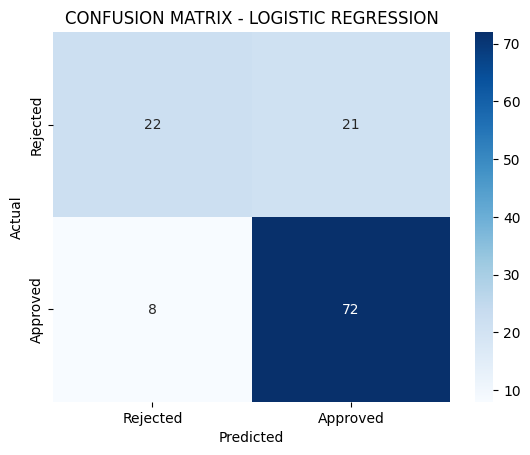

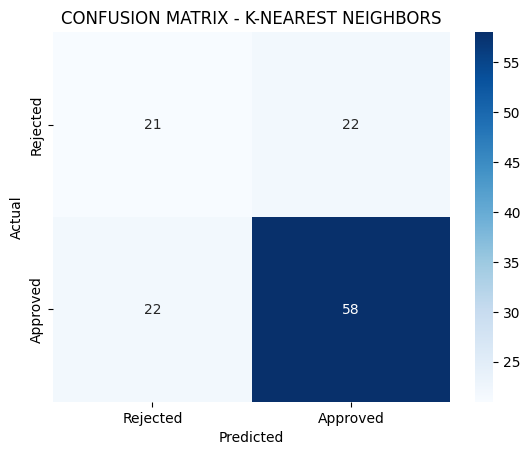

In [31]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = ['Rejected','Approved'],
            yticklabels = ['Rejected','Approved'])
plt.title('CONFUSION MATRIX - LOGISTIC REGRESSION')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

cm = confusion_matrix(y_test,y_pred_knn)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])
plt.title('CONFUSION MATRIX - K-NEAREST NEIGHBORS')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- **The Logistic Regression model correctly predicted 22 rejected loans and 72 approved loans. However, it incorrectly classified 21 rejected loans as approved and 8 approved loans as rejected. The model performed particularly well in identifying approved loans, showing strong prediction capability for the majority class while maintaining moderate performance for rejected loan cases.**

- **The KNN model correctly predicted 21 rejected loans and 58 approved loans. However, it misclassified 22 rejected loans as approved and 22 approved loans as rejected. Compared to Logistic Regression, the KNN model made more prediction errors and showed weaker performance in distinguishing between approved and rejected loan applications.**

# **Overall Business Summary**

1. **BUSINESS PROBLEM:**

     Financial institutions face challenges in efficiently and accurately determining whether a loan application should be approved or rejected. Manual decision-making can be slow, inconsistent, and influenced by bias.

     **Key business challenges:**

     - Risk of approving high-risk applicants
     - Loss of potential good customers due to manual errors
     - Imbalanced dataset affecting prediction reliability
     - Need for automated and data-driven decision system


2. **SOLUTION:**

    A machine learning-based loan approval prediction system was developed to automate the decision-making process.

     **Steps performed:**

     - Data cleaning and missing value handling
     - Exploratory Data Analysis (EDA)
     - Feature encoding (Label Encoding & One-Hot Encoding)
     - Feature scaling using StandardScaler
     - Handling class imbalance using SMOTE

     **Models trained:**

     - Logistic Regression
     - K-Nearest Neighbors

     **Model evaluation:**

     - Classification Report
     - Confusion Matrix

3. **KEY INSIGHTS (BUSINESS ANALYSIS):**

     - Credit history is the most important factor in loan approval
     - Applicant income shows moderate influence on loan amount
     - Dataset was slightly imbalanced before SMOTE
     - Majority of applicants fall into lower income range
     - Loan amounts are mostly concentrated in lower values
     - Outliers exist in income distribution

4. **RECOMMENDATIONS:**

     - **Model Deployment :** Use Logistic Regression for production due to better accuracy and balanced performance
     - **Risk Assessment Improvement :** Strong focus on Credit History while approving loans
     - **Data Monitoring :** Continuously monitor class imbalance in future datasets
     - **Decision Support System :** Integrate model into loan approval workflow for faster decisions

# **FINAL CONCLUSION:**

**Machine learning models were developed to predict loan approval using applicant financial and demographic data. The dataset was preprocessed using encoding, scaling, and SMOTE to improve model performance.**

**Two models, Logistic Regression and KNN, were trained and evaluated. Logistic Regression achieved better performance with higher accuracy and more balanced predictions across both classes.**

**Confusion matrix results also showed that Logistic Regression made fewer misclassifications compared to KNN, especially in identifying rejected loan applications.**

**"Hence, Logistic Regression is selected as the most suitable model for loan approval prediction."**